# Retail Sales Prediction Using Machine Learning Models

<p align="center">
    <img src="https://i.pinimg.com/originals/91/f6/6f/91f66fae35a6135a42ca2b8de4554964.gif" width="500">
</p>

## Machine Learning

### Author: Makarena Ampuero
### Course: Data Science
### May 2026

## Objective

The main objective of this project is to develop Machine Learning models capable of analyzing and predicting retail sales behavior from historical transaction data.

The specific objectives are:

- Perform data cleaning and preprocessing to ensure dataset quality.
- Explore sales patterns through descriptive statistics and data visualization.
- Create temporal and categorical features to improve model representation.
- Implement regression models using Decision Tree Regressor and Random Forest Regressor.
- Optimize regression models through hyperparameter tuning using GridSearchCV.
- Evaluate model performance using regression metrics such as MSE, RMSE and R² Score.
- Analyze feature importance to understand the main factors influencing sales predictions.
- Compare different modeling approaches considering feature selection and feature engineering.
- Develop an additional classification model to identify high and low sales transactions.
- Evaluate classification performance using metrics such as accuracy, classification report, confusion matrix and ROC-AUC.

# Introduction

Retail businesses generate large volumes of transactional data that can be analyzed to identify sales patterns, understand customer behavior and support decision-making processes.

This project focuses on analyzing a retail sales dataset and developing Machine Learning models to predict and understand sales behavior using customer, product and temporal information.

The main analysis implements regression models to estimate total sales amount using Decision Tree Regressor and Random Forest Regressor. Different modeling approaches were evaluated to analyze the influence of predictor variables, feature engineering techniques and model performance.

Additionally, a classification approach was developed as an extended analysis to predict whether a transaction represents a high or low sales event, providing an alternative business perspective.

The complete workflow includes data cleaning, exploratory data analysis, feature transformation, model optimization, performance evaluation and model interpretation.

# 1. Import Libraries

In [469]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Data preprocessing
from sklearn.preprocessing import LabelEncoder


# Data splitting and optimization
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)


# Regression models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


# Classification models
from sklearn.ensemble import RandomForestClassifier


# Regression metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


# Model interpretation
from sklearn.inspection import permutation_importance

In [470]:
sales_color = "forestgreen"

# 2. Load Dataset

In [471]:
retail = pd.read_csv("../data/retail_sales_dataset.csv")

## Dataset Preview

In [472]:
retail.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [473]:
retail.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


The dataset was successfully loaded. The first and last rows were reviewed to understand the initial structure, available variables and transaction records.

## Dataset Dimensions

In [474]:
retail.shape

(1000, 9)

The dataset dimensions were checked to identify the number of observations and available features before preprocessing.

## Dataset Information

In [475]:
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


The dataset information was reviewed to identify data types, missing values and the initial structure of each feature.

## Descriptive Statistics

In [476]:
retail.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [477]:
numeric_columns = retail.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
)


descriptive_statistics = pd.DataFrame({

    "Mean": numeric_columns.mean(),

    "Median": numeric_columns.median(),

    "Mode": numeric_columns.mode().iloc[0],

    "Standard Deviation": numeric_columns.std(),

    "Minimum": numeric_columns.min(),

    "Maximum": numeric_columns.max(),

    "Range": (
        numeric_columns.max()
        -
        numeric_columns.min()
    )

})


descriptive_statistics

,Mean,Median,Mode,Standard Deviation,Minimum,Maximum,Range
Transaction ID,500.500,500.5,1.0,288.819436,1,1000,999
Age,41.392,42.0,43.0,13.681430,18,64,46
Quantity,2.514,3.0,4.0,1.132734,1,4,3
Price per Unit,179.890,50.0,50.0,189.681356,25,500,475
Total Amount,456.000,135.0,50.0,559.997632,25,2000,1975


The descriptive statistics show the general behavior of the numerical variables in the dataset.

Customer age ranges from 18 to 64 years old, with an average age close to 41 years. Sales amounts show a wide range, indicating differences in customer purchasing behavior.

Quantity values remain within a small range, while price and total sales present higher variability due to differences between product categories and purchase amounts.

# 3. Data Cleaning

### Missing Values

In [478]:
retail.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

The missing values analysis showed that the dataset does not contain null values.

Therefore, no imputation or record removal was required, preserving the original structure and information of the dataset.

### Duplicate Values

In [479]:
retail.duplicated().sum()

np.int64(0)

The duplicate values analysis showed that there are no duplicated records in the dataset.

Since all transactions are unique, no duplicate removal was necessary during the data cleaning process.

### Data Type

In [480]:
retail.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

### Date Conversion

In [481]:
retail["Date"] = pd.to_datetime(retail["Date"])

The Date column was converted into datetime format to allow temporal feature extraction for the predictive models.

# 4. Feature Transformation

### Temporal Feature Creation

In [482]:
retail["Month"] = retail["Date"].dt.month

retail["Day"] = retail["Date"].dt.day

retail["DayOfWeek"] = retail["Date"].dt.day_name()

retail["Year"] = retail["Date"].dt.year

New temporal variables were created from the original transaction date to capture possible sales patterns related to months, days and weekdays.

### Removing Non-Predictive Variables

In [483]:
retail.drop(
    columns=[
        "Transaction ID",
        "Customer ID",
        "Date"
    ],
    inplace=True
)

Transaction ID and Customer ID were removed because they represent unique identifiers without predictive value.

The original Date column was also removed after extracting relevant temporal information.

### Dataset After Feature Transformation

In [484]:
retail.head()

,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Day,DayOfWeek,Year
0,Male,34,Beauty,3,50,150,11,24,Friday,2023
1,Female,26,Clothing,2,500,1000,2,27,Monday,2023
2,Male,50,Electronics,1,30,30,1,13,Friday,2023
3,Male,37,Clothing,1,500,500,5,21,Sunday,2023
4,Male,30,Beauty,2,50,100,5,6,Saturday,2023


In [485]:
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Gender            1000 non-null   str  
 1   Age               1000 non-null   int64
 2   Product Category  1000 non-null   str  
 3   Quantity          1000 non-null   int64
 4   Price per Unit    1000 non-null   int64
 5   Total Amount      1000 non-null   int64
 6   Month             1000 non-null   int32
 7   Day               1000 non-null   int32
 8   DayOfWeek         1000 non-null   str  
 9   Year              1000 non-null   int32
dtypes: int32(3), int64(4), str(3)
memory usage: 66.5 KB


After feature transformation, non-predictive identifiers were removed and new temporal variables were added. The updated dataset structure was reviewed before exploratory visual analysis and model preparation.

## Target Variable Definition

For this regression analysis, Total Amount was selected as the target variable because it represents the total sales value generated by each transaction.

Unlike classification problems, the objective is not to assign sales categories but to predict a continuous numerical value using regression models.

# 5. Exploratory Data Analysis (EDA)

## Data Visualization

### Numerical Variable Distribution

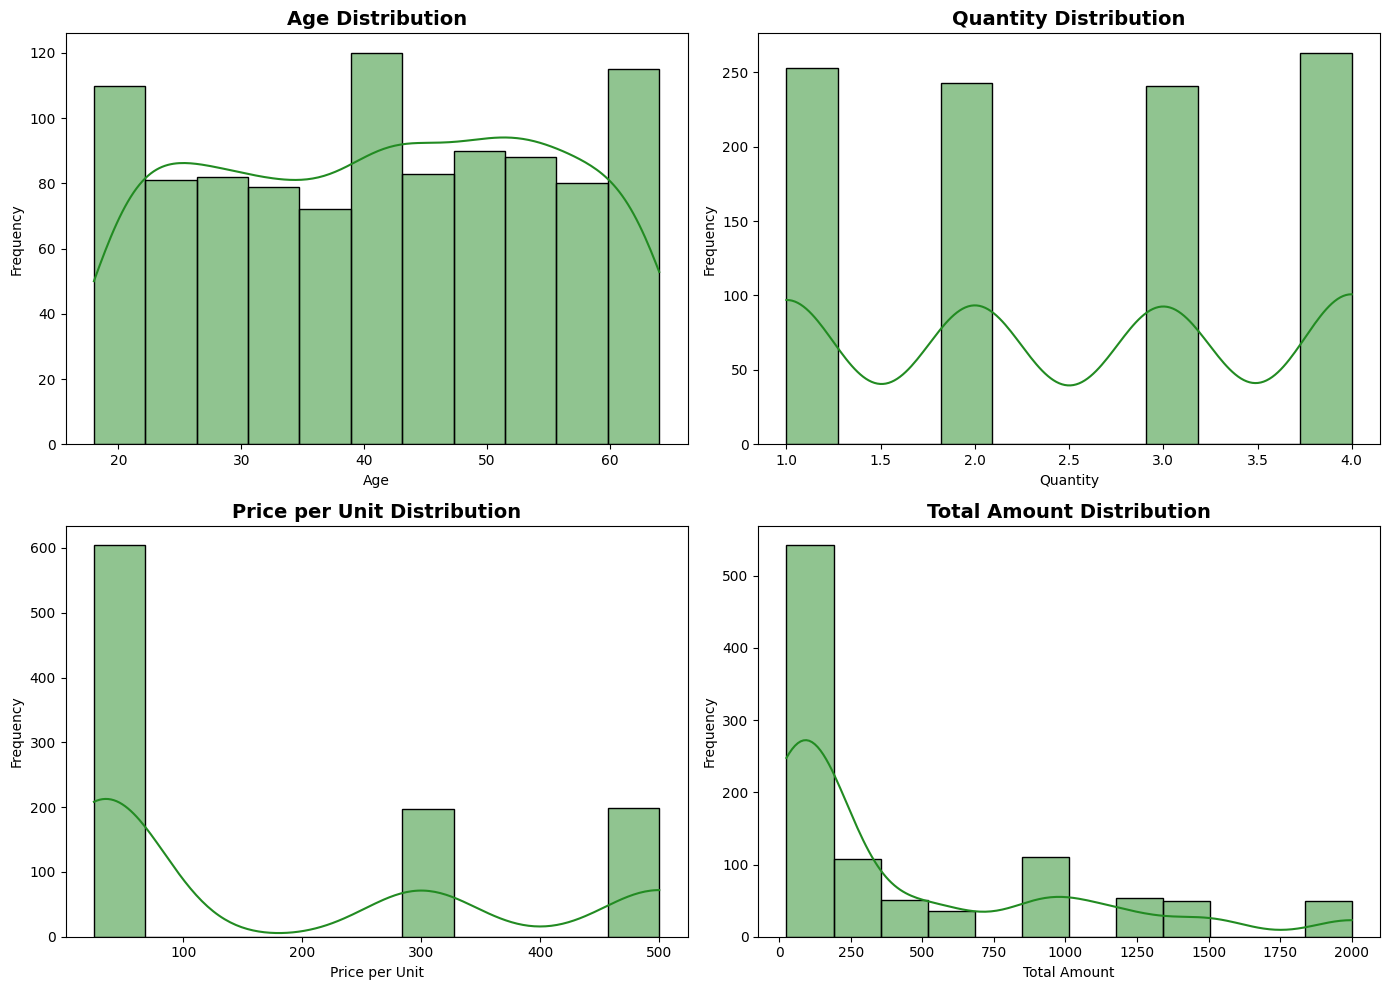

In [486]:
numerical_features = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)


axes = axes.flatten()


for i, column in enumerate(
    numerical_features
):

    sns.histplot(
        data=retail,
        x=column,
        kde=True,
        color=sales_color,
        ax=axes[i]
    )


    axes[i].set_title(
        f"{column} Distribution",
        fontsize=14,
        fontweight="bold"
    )


    axes[i].set_xlabel(
        column
    )


    axes[i].set_ylabel(
        "Frequency"
    )


plt.tight_layout()


plt.show()

The numerical variable distributions show different patterns within the retail dataset.

Customer age presents a relatively balanced distribution across different age groups, suggesting that purchases are not concentrated in a specific customer age range.

Quantity shows a uniform distribution between 1 and 4 purchased items, indicating similar purchase frequency across different quantities.

Price per Unit presents a more uneven distribution, with a higher concentration of products in lower price ranges. This suggests that lower-priced items represent a larger proportion of transactions.

Total Amount shows a right-skewed distribution, where most transactions correspond to lower sales values while fewer purchases reach higher amounts. This indicates that high-value transactions occur less frequently.

### Categorical Variable Distribution

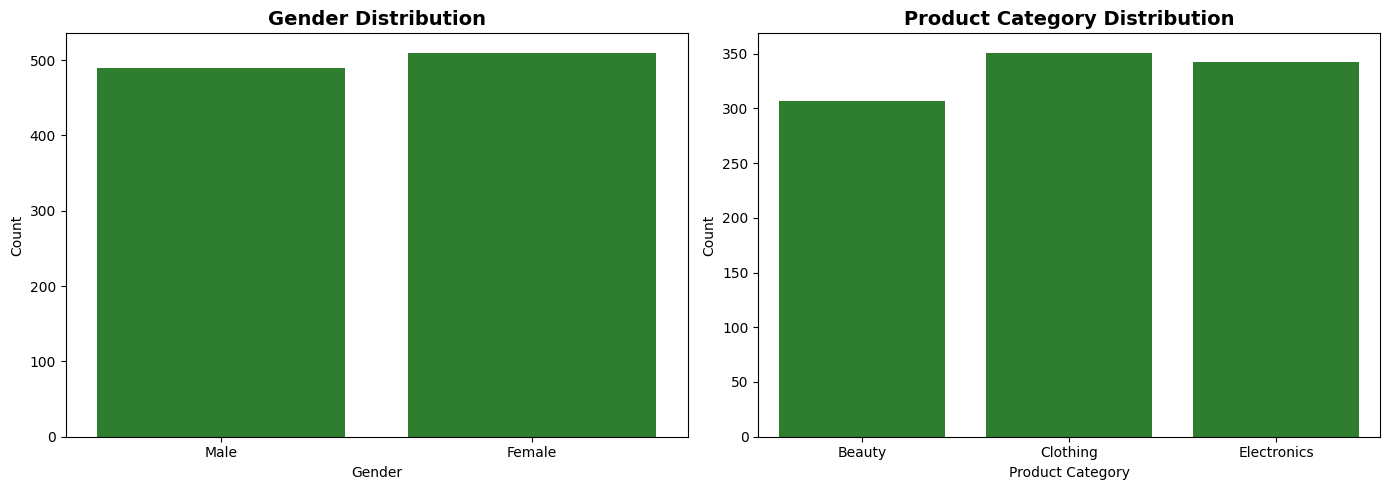

In [487]:
categorical_features = [
    "Gender",
    "Product Category"
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)


for i, column in enumerate(
    categorical_features
):

    sns.countplot(
        data=retail,
        x=column,
        color=sales_color,
        ax=axes[i]
    )


    axes[i].set_title(
        f"{column} Distribution",
        fontsize=14,
        fontweight="bold"
    )


    axes[i].set_xlabel(
        column
    )


    axes[i].set_ylabel(
        "Count"
    )


plt.tight_layout()


plt.show()

The categorical variable analysis shows a balanced distribution between male and female customers, indicating that the dataset does not present a strong gender imbalance.

Product categories also show a relatively even distribution across Beauty, Clothing and Electronics. Clothing represents the highest number of transactions, followed closely by Electronics and Beauty.

This balance allows the model to learn from different customer groups and product categories without a major dominance from a single class.

### Correlation Matrix

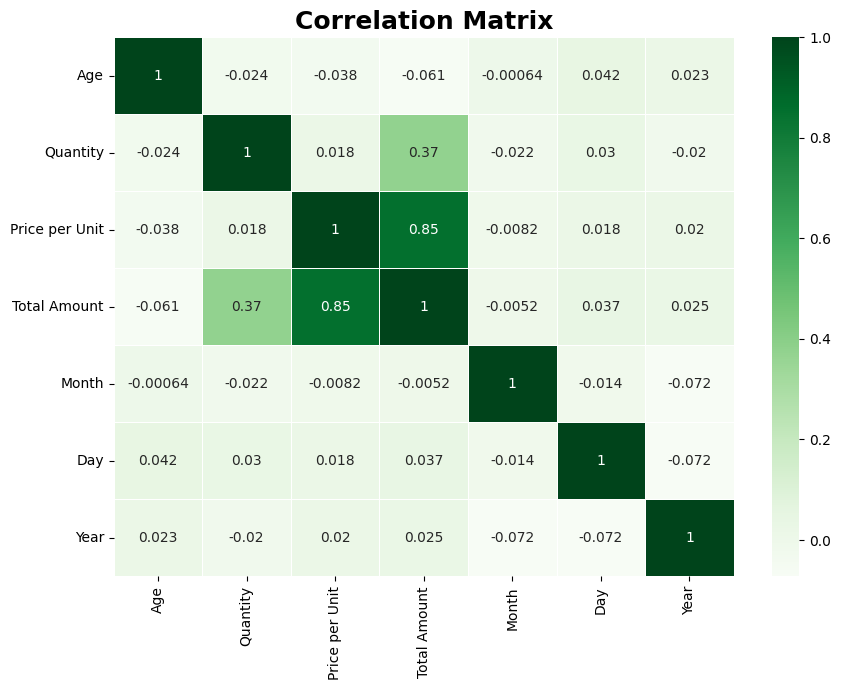

In [488]:
fig, ax = plt.subplots(
    figsize=(10,7)
)


sns.heatmap(
    retail.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="Greens",
    linewidths=0.5,
    ax=ax
)


ax.set_title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)


plt.show()

The correlation matrix shows the relationships between the numerical variables in the dataset.

Price per Unit presents the strongest positive correlation with Total Amount, indicating that product price has a major influence on the final sales value. Quantity also shows a moderate positive relationship with Total Amount, suggesting that purchasing more items increases the transaction value.

Other variables such as Age, Month, Day and Year show weak correlations with sales, meaning they do not present a strong linear relationship with the target variable.

These results suggest that price and quantity are the main numerical drivers behind sales behavior.

### Variable Relationships

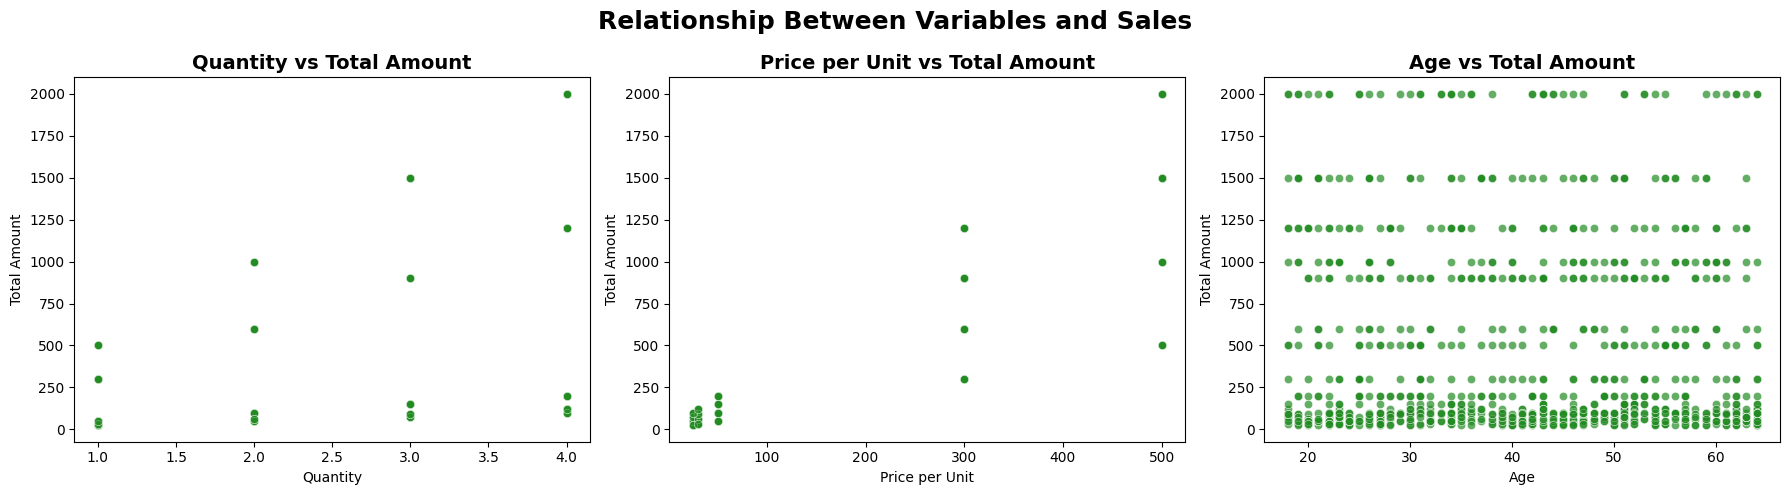

In [489]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)


relationships = [
    "Quantity",
    "Price per Unit",
    "Age"
]


for i, column in enumerate(
    relationships
):

    sns.scatterplot(
        data=retail,
        x=column,
        y="Total Amount",
        color=sales_color,
        alpha=0.7,
        ax=axes[i]
    )


    axes[i].set_title(
        f"{column} vs Total Amount",
        fontsize=14,
        fontweight="bold"
    )


    axes[i].set_xlabel(
        column
    )


    axes[i].set_ylabel(
        "Total Amount"
    )


fig.suptitle(
    "Relationship Between Variables and Sales",
    fontsize=18,
    fontweight="bold"
)


plt.tight_layout()


plt.show()

The relationship analysis shows how different variables interact with the Total Amount generated in each transaction.

Quantity presents a positive relationship with sales, where transactions with more purchased items tend to reach higher total values.

Price per Unit shows the clearest relationship with Total Amount. Higher product prices generally result in higher sales amounts, confirming that price is one of the strongest predictors in the dataset.

Age does not show a clear pattern with sales values, suggesting that customer age alone does not strongly determine the transaction amount.

### Outlier Detection

In [490]:
outlier_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

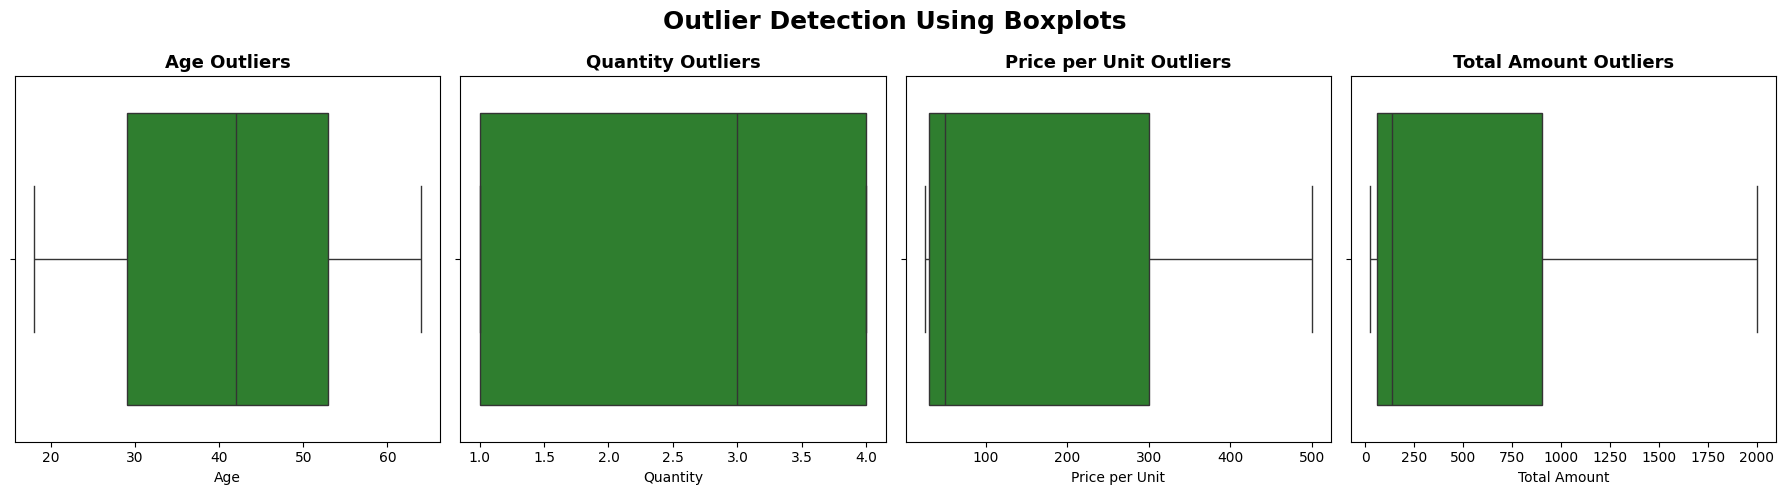

In [491]:
fig, axes = plt.subplots(
    1,
    len(outlier_columns),
    figsize=(18,5)
)


for ax, column in zip(
    axes,
    outlier_columns
):

    sns.boxplot(
        data=retail,
        x=column,
        color=sales_color,
        ax=ax
    )


    ax.set_title(
        f"{column} Outliers",
        fontsize=13,
        fontweight="bold"
    )


    ax.set_xlabel(
        column
    )


fig.suptitle(
    "Outlier Detection Using Boxplots",
    fontsize=18,
    fontweight="bold"
)


plt.tight_layout()


plt.show()

The boxplot analysis was performed to identify possible outliers within the main numerical variables.

Age and Quantity show consistent distributions without extreme values, indicating normal customer and transaction behavior.

Price per Unit and Total Amount present a wider range of values due to differences in product prices and purchase sizes. However, these values represent valid sales transactions rather than data errors.

Therefore, no outlier removal was applied in order to preserve important information about high-value purchases.

In [492]:
for column in outlier_columns:

    Q1 = retail[column].quantile(
        0.25
    )

    Q3 = retail[column].quantile(
        0.75
    )

    IQR = Q3 - Q1


    lower_limit = Q1 - 1.5 * IQR


    upper_limit = Q3 + 1.5 * IQR


    outliers = retail[
        (retail[column] < lower_limit)
        |
        (retail[column] > upper_limit)
    ]


    print(
        column,
        ":",
        len(outliers),
        "outliers"
    )

Age : 0 outliers
Quantity : 0 outliers
Price per Unit : 0 outliers
Total Amount : 0 outliers


The IQR method and boxplot analysis were applied to detect possible outliers in the numerical variables.

The results showed no outliers for Age, Quantity, Price per Unit and Total Amount. Although Price per Unit and Total Amount present wider value ranges, these differences represent normal variations in product prices and transaction values.

Since no abnormal values were detected, no outlier removal was required and all observations were preserved for the modeling process.

# 6. Preprocessing

Before training the regression models, categorical variables were transformed into numerical format and the dataset was divided into predictor variables and the target variable.

## Feature and Target Selection

The dataset was divided into independent variables (features) and the target variable.  
For this regression problem, `Total Amount` was selected as the target variable because the objective is to predict total retail sales.

In [493]:
X = retail.drop(
    columns="Total Amount"
)


y = retail["Total Amount"]

In [494]:
print(
    "Features shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

Features shape: (1000, 9)
Target shape: (1000,)


In [495]:
numeric_features = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Year",
    "Month",
    "Day"
]


categorical_features = [
    "Gender",
    "Product Category",
    "DayOfWeek"
]

In [496]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Train Test Split

The dataset was split into training and testing subsets.  
80% of the data was used to train the models and 20% was reserved to evaluate their performance with unseen data.

In [497]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [498]:
print(
    "Training data:",
    X_train.shape
)


print(
    "Testing data:",
    X_test.shape
)

Training data: (700, 9)
Testing data: (300, 9)


In [499]:
X_train_processed = preprocessor.fit_transform(
    X_train
)


X_test_processed = preprocessor.transform(
    X_test
)

The dataset was split using a 70/30 proportion, assigning 70% of the observations for training and 30% for testing.

This configuration provides a larger evaluation set to better analyze how the regression models generalize to unseen data.

# 7. Predictive Modeling

Regression models were implemented to predict the Total Amount variable using customer, product and temporal information.

Different modeling approaches were evaluated to analyze model performance, feature influence and generalization capacity.

## Baseline Model: All Available Features

The baseline approach uses all available predictor variables after preprocessing. This model establishes an initial performance reference before applying feature selection or additional transformations.

### Decision Tree Regressor Model

A Decision Tree Regressor model was implemented to predict total retail sales.

This algorithm works by splitting the dataset into decision rules, allowing it to identify patterns between customer, product and transaction variables.

In [500]:
tree_model = DecisionTreeRegressor(
    random_state=42
)


tree_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [501]:
tree_predictions = tree_model.predict(
    X_test_processed
)

#### Decision Tree Regressor Evaluation

In [502]:
tree_mse = mean_squared_error(
    y_test,
    tree_predictions
)


tree_rmse = np.sqrt(
    tree_mse
)


tree_r2 = r2_score(
    y_test,
    tree_predictions
)


print(
    "Decision Tree Results"
)

print(
    "MSE:",
    tree_mse
)

print(
    "RMSE:",
    tree_rmse
)

print(
    "R2 Score:",
    tree_r2
)

Decision Tree Results
MSE: 0.0
RMSE: 0.0
R2 Score: 1.0


The initial Decision Tree Regressor achieved a perfect performance with an R2 Score of 1.0 and no prediction error.

Although this indicates that the model was able to exactly predict the target values, this result requires further analysis since perfect performance can suggest that the model is relying too heavily on highly related variables.

Additional evaluation was performed to understand the relationship between the input features and the target variable.

### Random Forest Regressor

In [503]:
forest_model = RandomForestRegressor(
    random_state=42
)


forest_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [504]:
forest_predictions = forest_model.predict(
    X_test_processed
)

#### Random Forest Regressor Evaluation

In [505]:
forest_mse = mean_squared_error(
    y_test,
    forest_predictions
)


forest_rmse = np.sqrt(
    forest_mse
)


forest_r2 = r2_score(
    y_test,
    forest_predictions
)


print(
    "Random Forest Results"
)


print(
    "MSE:",
    forest_mse
)


print(
    "RMSE:",
    forest_rmse
)


print(
    "R2 Score:",
    forest_r2
)

Random Forest Results
MSE: 0.0
RMSE: 0.0
R2 Score: 1.0


The Random Forest Regressor also achieved a perfect prediction performance with an R2 Score of 1.0 and zero prediction error.

Since both tree-based models produced identical perfect results, the outcome suggests that the dataset contains variables with a very strong relationship to the target variable rather than only reflecting model complexity.

Further analysis was performed through correlation analysis and feature importance evaluation to identify which variables had the greatest influence on the predictions.

## Initial Results Analysis

In [506]:
initial_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "MSE": [
        tree_mse,
        forest_mse
    ],

    "RMSE": [
        tree_rmse,
        forest_rmse
    ],

    "R2 Score": [
        tree_r2,
        forest_r2
    ]

})


initial_results

,Model,MSE,RMSE,R2 Score
0,Decision Tree,0.0,0.0,1.0
1,Random Forest,0.0,0.0,1.0


The baseline model comparison shows that both Decision Tree and Random Forest achieved perfect performance, obtaining an R2 Score of 1.0 with no prediction errors.

Although this indicates that both models were able to accurately reproduce the target variable, the identical results suggest that the predictions may be strongly influenced by specific features within the dataset.

For this reason, additional analysis was performed to evaluate feature relationships and understand which variables were driving the model performance.

### Target Correlation

In [507]:
target_correlation = (
    retail
    .corr(numeric_only=True)["Total Amount"]
    .sort_values(
        ascending=False
    )
)


target_correlation

Total Amount      1.000000
Price per Unit    0.851925
Quantity          0.373707
Day               0.036889
Year              0.024714
Month            -0.005197
Age              -0.060568
Name: Total Amount, dtype: float64

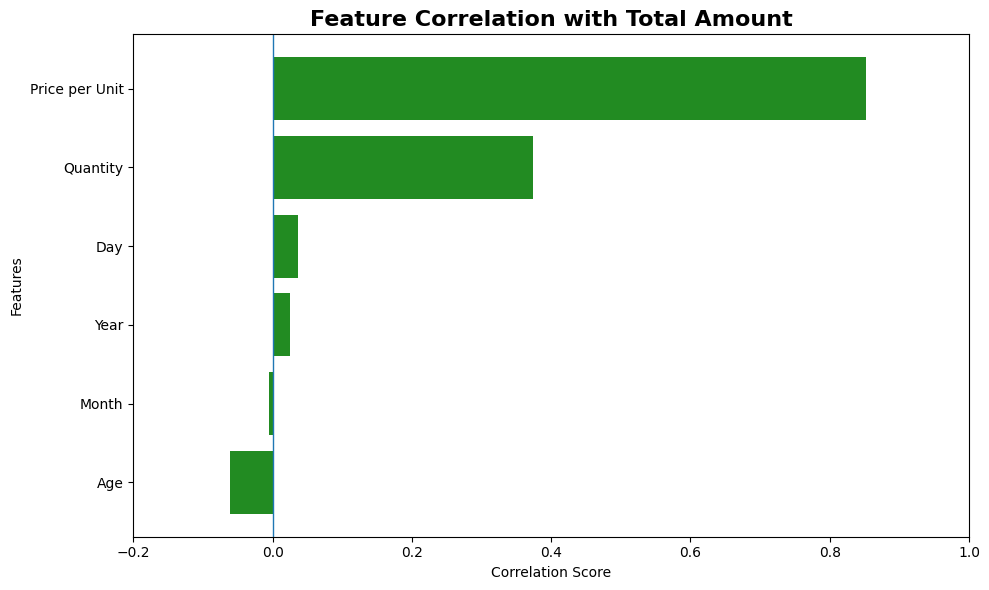

In [508]:
target_correlation = (
    retail
    .corr(numeric_only=True)["Total Amount"]
    .drop("Total Amount")
    .sort_values()
)


fig, ax = plt.subplots(
    figsize=(10,6)
)


ax.barh(
    target_correlation.index,
    target_correlation.values,
    color=sales_color
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_title(
    "Feature Correlation with Total Amount",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Correlation Score"
)


ax.set_ylabel(
    "Features"
)


ax.set_xlim(
    -0.2,
    1
)


plt.tight_layout()


plt.show()

The correlation analysis shows that Price per Unit has the strongest positive relationship with Total Amount, followed by Quantity.

This result indicates that most of the sales value variation is explained by price-related information and the number of purchased items. Other variables such as customer

### Feature Importance

In [509]:
feature_names = preprocessor.get_feature_names_out()

In [510]:
initial_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": forest_model.feature_importances_

})


initial_importance = initial_importance.sort_values(
    by="Importance",
    ascending=True
)


initial_importance

,Feature,Importance
0,categorical__Gender_Male,0.000000
1,categorical__Product Category_Clothing,0.000000
2,categorical__Product Category_Electronics,0.000000
3,categorical__DayOfWeek_Monday,0.000000
4,categorical__DayOfWeek_Saturday,0.000000
5,categorical__DayOfWeek_Sunday,0.000000
6,categorical__DayOfWeek_Thursday,0.000000
7,categorical__DayOfWeek_Tuesday,0.000000
8,categorical__DayOfWeek_Wednesday,0.000000
9,remainder__Age,0.000000


In [511]:
feature_names = preprocessor.get_feature_names_out()


importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": forest_model.feature_importances_

})


importance["Feature"] = (
    importance["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)


importance = importance.sort_values(
    by="Importance",
    ascending=True
)

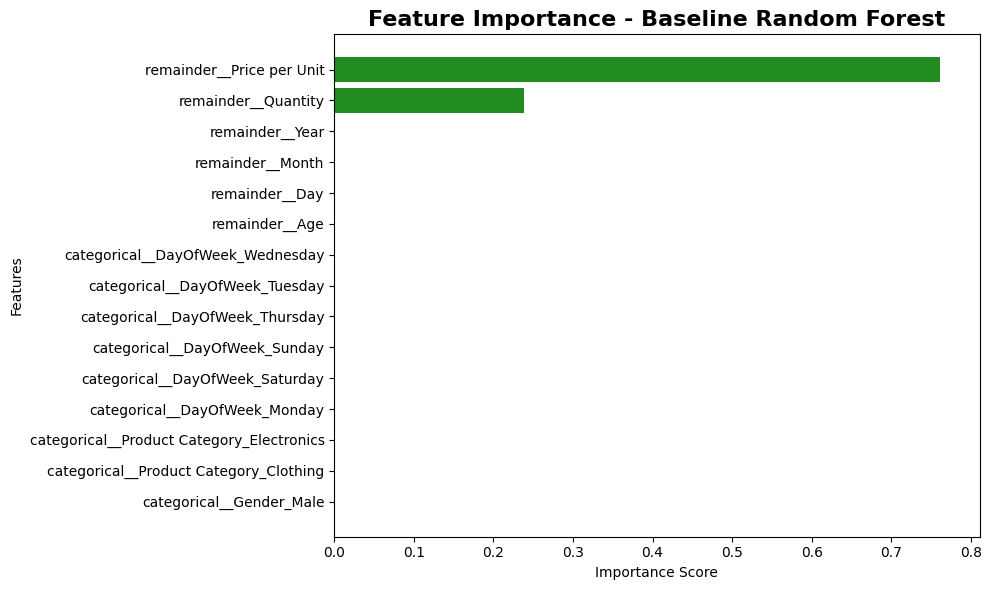

In [512]:
fig, ax = plt.subplots(
    figsize=(10,6)
)


ax.barh(
    initial_importance["Feature"],
    initial_importance["Importance"],
    color=sales_color
)


ax.set_title(
    "Feature Importance - Baseline Random Forest",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Importance Score"
)


ax.set_ylabel(
    "Features"
)


ax.set_xlim(
    0,
    initial_importance["Importance"].max() + 0.05
)


plt.tight_layout()


plt.show()

The baseline Random Forest model identified Price per Unit and Quantity as the most influential variables for predicting Total Amount.

After applying ColumnTransformer and OneHotEncoder for categorical preprocessing, categorical features showed minimal contribution compared with numerical variables.

The high importance of Price per Unit and Quantity supports the previous correlation analysis and confirms that the baseline model performance was mainly influenced by the direct mathematical relationship between these variables and the target.

## Adjusted Model: Removing Highly Correlated Feature

Based on the initial analysis, a second modeling approach was developed by removing Price per Unit to evaluate model performance without variables directly related to the target calculation.

The comparison between both experiments demonstrated the importance of detecting data leakage during machine learning projects.

While the first models achieved perfect metrics, this performance was mainly explained by the mathematical relationship between Price per Unit and Total Amount.

After removing this variable, the models showed lower but more realistic performance, highlighting the need for additional predictive features.

### Feature Selection

In [513]:
X_adjusted = retail.drop(

    [
        "Total Amount",
        "Price per Unit",
        "Quantity"
    ],

    axis=1

)


y_adjusted = retail["Total Amount"]

### Train Test Split

In [514]:
X_train_adjusted, X_test_adjusted, y_train_adjusted, y_test_adjusted = train_test_split(

    X_adjusted,
    y_adjusted,
    test_size=0.3,
    random_state=42

)

### Column Transformer

In [515]:
X_train_adjusted_processed = preprocessor.fit_transform(
    X_train_adjusted
)


X_test_adjusted_processed = preprocessor.transform(
    X_test_adjusted
)

### Adjusted Decision Tree Regressor

In [516]:
tree_model = DecisionTreeRegressor(
    random_state=42
)


tree_model.fit(

    X_train_adjusted_processed,
    y_train_adjusted

)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [517]:
tree_predictions = tree_model.predict(

    X_test_adjusted_processed

)

#### Adjusted Decision Tree Regressor Evaluation

In [518]:
tree_mse = mean_squared_error(

    y_test_adjusted,
    tree_predictions

)


tree_rmse = np.sqrt(

    tree_mse

)


tree_r2 = r2_score(

    y_test_adjusted,
    tree_predictions

)


print("Adjusted Decision Tree Results")

print("MSE:", tree_mse)

print("RMSE:", tree_rmse)

print("R2 Score:", tree_r2)

Adjusted Decision Tree Results
MSE: 631992.9166666666
RMSE: 794.9798215468533
R2 Score: -1.2608933950423173


After removing the strongest price-related feature, the Decision Tree Regressor showed a significant decrease in predictive performance.

The negative R2 Score indicates that the model was not able to generalize well using the remaining variables and performed worse than a simple baseline prediction based on the average sales value.

This result suggests that the original model performance was highly influenced by price information and that additional optimization is required to improve model generalization.

### Overfitting Analysis

In [519]:
print(
    "Training R2:",
    tree_model.score(
        X_train_adjusted_processed,
        y_train_adjusted
    )
)


print(
    "Testing R2:",
    tree_model.score(
        X_test_adjusted_processed,
        y_test_adjusted
    )
)

Training R2: 0.9929152850948385
Testing R2: -1.2608933950423173


The overfitting analysis shows a large difference between training and testing performance.

The Decision Tree achieved a very high Training R2 Score, indicating that the model learned the training data almost perfectly. However, the negative Testing R2 Score shows that it was not able to generalize well on unseen data.

This behavior indicates overfitting, where the model captures patterns specific to the training dataset instead of learning relationships that can be applied to new observations.

For this reason, hyperparameter optimization was performed using GridSearchCV to control model complexity and improve generalization.

### Decision Tree Optimization - GridSearchCV

In [520]:
tree_params = {

    "max_depth": [
        2,
        3,
        5,
        10
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        5
    ]

}

In [521]:
tree_grid = GridSearchCV(

    DecisionTreeRegressor(
        random_state=42
    ),

    tree_params,

    cv=5,

    scoring="r2"

)

In [522]:
tree_grid.fit(

    X_train_adjusted_processed,
    y_train_adjusted

)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [523]:
tree_grid.best_params_

{'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [524]:
best_tree = tree_grid.best_estimator_


optimized_tree_predictions = best_tree.predict(
    X_test_adjusted_processed
)

#### Optimized Decision Tree Evaluation

In [525]:
best_tree_predictions = best_tree.predict(

    X_test_adjusted_processed

)

In [526]:
best_tree_mse = mean_squared_error(

    y_test_adjusted,
    best_tree_predictions

)


best_tree_rmse = np.sqrt(

    best_tree_mse

)


best_tree_r2 = r2_score(

    y_test_adjusted,
    best_tree_predictions

)


print("Optimized Decision Tree Results")

print("MSE:", best_tree_mse)

print("RMSE:", best_tree_rmse)

print("R2 Score:", best_tree_r2)

Optimized Decision Tree Results
MSE: 285990.7112828211
RMSE: 534.7809937561553
R2 Score: -0.023104046154712288


After applying GridSearchCV optimization, the Decision Tree Regressor showed an improvement compared with the initial adjusted model.

Although the R2 Score remained slightly negative, the optimization process reduced model complexity and helped decrease overfitting between training and testing performance.

The limited predictive performance suggests that, after removing the variables directly related to the target calculation, the remaining customer and temporal features do not provide enough information to accurately explain Total Amount variations.

### Adjusted Random Forest Regressor

In [527]:
forest_model = RandomForestRegressor(

    random_state=42

)


forest_model.fit(

    X_train_adjusted_processed,
    y_train_adjusted

)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [528]:
forest_predictions = forest_model.predict(

    X_test_adjusted_processed

)

#### Adjusted Random Forest Regressor Evaluation

In [529]:
forest_mse = mean_squared_error(

    y_test_adjusted,
    forest_predictions

)


forest_rmse = np.sqrt(

    forest_mse

)


forest_r2 = r2_score(

    y_test_adjusted,
    forest_predictions

)

adjusted_forest_r2 = forest_r2
print("Adjusted Random Forest Results")

print("MSE:", forest_mse)

print("RMSE:", forest_rmse)

print("R2 Score:", forest_r2)

Adjusted Random Forest Results
MSE: 301748.94220954267
RMSE: 549.3167958560367
R2 Score: -0.07947758971859953


The adjusted Random Forest Regressor showed limited predictive performance after removing the variables directly related to the target calculation.

Although Random Forest usually improves generalization by combining multiple decision trees, the model obtained a negative R2 Score, indicating that the remaining features were not sufficient to accurately predict Total Amount.

This result confirms that the high performance observed in the baseline model was mainly caused by the strong mathematical relationship between Price per Unit, Quantity, and the target variable rather than hidden customer purchasing patterns.

### Random Forest Optimization - GridSearchCV

In [530]:
param_grid = {

    "n_estimators": [50, 100, 200],

    "max_depth": [2, 5, 10, None],

    "min_samples_split": [2, 5, 10]

}


grid_forest = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid,

    cv=5,

    scoring="r2"

)


grid_forest.fit(

    X_train_adjusted_processed,
    y_train_adjusted

)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Cont

In [531]:
best_forest = grid_forest.best_estimator_


print(
    grid_forest.best_params_
)

{'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [532]:
best_forest_predictions = best_forest.predict(

    X_test_adjusted_processed

)

#### Optimized Random Forest Evaluation

In [533]:
best_forest_mse = mean_squared_error(

    y_test_adjusted,
    best_forest_predictions

)


best_forest_rmse = np.sqrt(

    best_forest_mse

)


best_forest_r2 = r2_score(

    y_test_adjusted,
    best_forest_predictions

)
adjusted_optimized_forest_r2 = best_forest_r2

print("Optimized Random Forest Results")

print("MSE:", best_forest_mse)

print("RMSE:", best_forest_rmse)

print("R2 Score:", best_forest_r2)

Optimized Random Forest Results
MSE: 275344.9835035874
RMSE: 524.7332498551882
R2 Score: 0.014980012996511638


After hyperparameter optimization with GridSearchCV, the Random Forest Regressor showed a slight improvement compared with the initial adjusted model.

The R2 Score increased from a negative value to a slightly positive result, indicating that hyperparameter tuning helped improve model generalization.

However, the predictive performance remained limited, showing that customer characteristics, product category, and temporal variables alone were not sufficient to accurately estimate Total Amount.

This reinforces that the strong baseline performance was mainly influenced by variables directly related to the target calculation rather than general purchasing patterns.

### Adjusted Model Comparision

In [534]:
adjusted_tree_r2 = tree_r2

adjusted_optimized_tree_r2 = best_tree_r2

adjusted_forest_r2 = forest_r2

adjusted_optimized_forest_r2 = best_forest_r2

In [535]:
adjusted_comparison = pd.DataFrame({

    "Model": [

        "Decision Tree",
        "Optimized Decision Tree",
        "Random Forest",
        "Optimized Random Forest"

    ],

    "R2 Score": [

        adjusted_tree_r2,
        adjusted_optimized_tree_r2,
        adjusted_forest_r2,
        adjusted_optimized_forest_r2

    ]

})


adjusted_comparison

,Model,R2 Score
0,Decision Tree,-1.260893
1,Optimized Decision Tree,-0.023104
2,Random Forest,-0.079478
3,Optimized Random Forest,0.014980


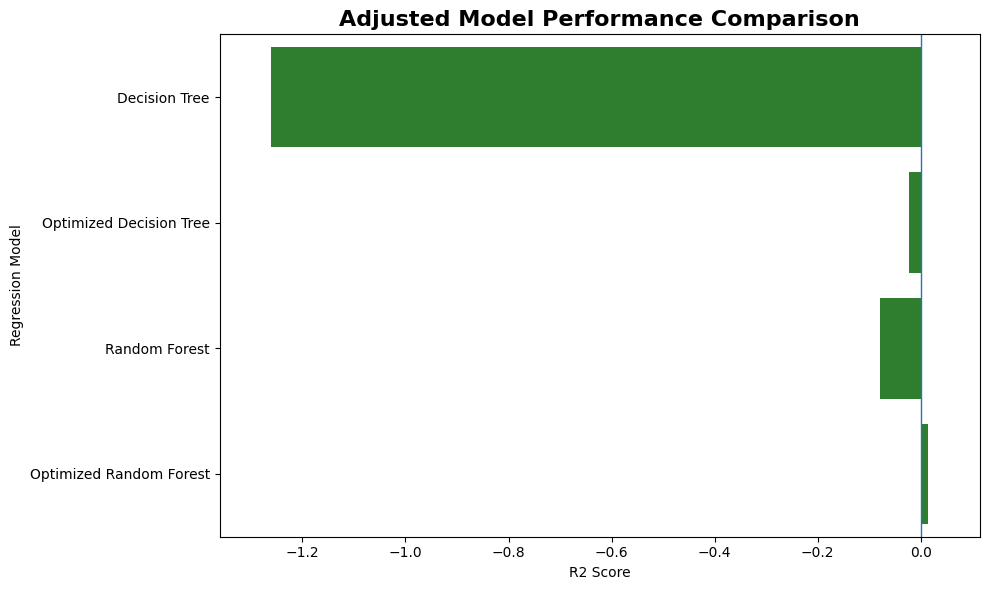

In [ ]:
fig, ax = plt.subplots(
    figsize=(10,6)
)


sns.barplot(
    data=adjusted_comparison,
    x="R2 Score",
    y="Model",
    color=sales_color,
    ax=ax
)


ax.set_title(
    "Adjusted Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "R2 Score"
)


ax.set_ylabel(
    "Regression Model"
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_xlim(
    adjusted_comparison["R2 Score"].min() - 0.1,
    adjusted_comparison["R2 Score"].max() + 0.1
)


plt.tight_layout()


plt.show()

The adjusted model comparison shows the impact of removing the strongest predictor and applying hyperparameter optimization.

Both initial models presented low generalization performance, especially the Decision Tree, which obtained a negative R2 Score due to overfitting.

After applying GridSearchCV, both Decision Tree and Random Forest improved their results, achieving positive R2 Scores. The Optimized Random Forest presented the best performance among the adjusted models.

However, the overall performance remained limited, confirming that removing all price-related information reduced the predictive capacity of the models.

### Feature Importance 

In [ ]:
feature_names = preprocessor.get_feature_names_out()


importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": forest_model.feature_importances_

})


importance["Feature"] = (
    importance["Feature"]
    .str.replace("categorical__", "")
    .str.replace("remainder__", "")
)


importance = importance.sort_values(
    by="Importance",
    ascending=True
)


importance

,Feature,Importance
12,Year,0.000000
6,DayOfWeek_Thursday,0.022236
8,DayOfWeek_Wednesday,0.023581
5,DayOfWeek_Sunday,0.025107
7,DayOfWeek_Tuesday,0.026354
3,DayOfWeek_Monday,0.028121
4,DayOfWeek_Saturday,0.029071
1,Product Category_Clothing,0.038227
2,Product Category_Electronics,0.043649
0,Gender_Male,0.044810


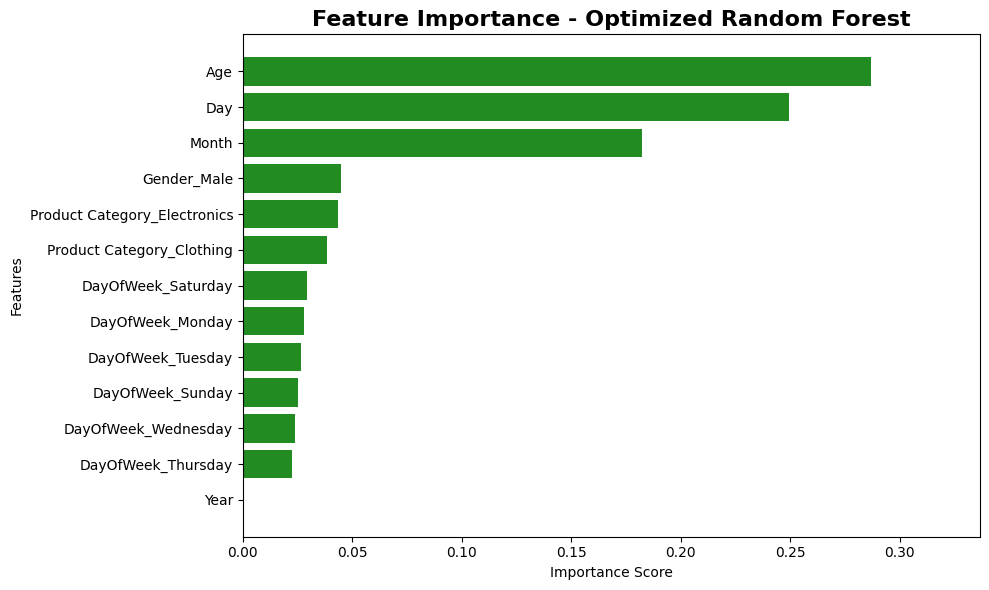

In [ ]:
fig, ax = plt.subplots(
    figsize=(10,6)
)


ax.barh(
    importance["Feature"],
    importance["Importance"],
    color=sales_color
)


ax.set_title(
    "Feature Importance - Optimized Random Forest",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Importance Score"
)


ax.set_ylabel(
    "Features"
)


ax.set_xlim(
    0,
    importance["Importance"].max() + 0.05
)


plt.tight_layout()


plt.show()

After removing Price per Unit, the feature importance analysis shows how the Optimized Random Forest model redistributed the importance among the remaining variables.

Quantity became the most relevant predictor, while temporal and customer-related variables provided additional information with lower influence.

This confirms that the adjusted model relies on more general transaction patterns, but the absence of detailed price information limits its ability to accurately predict Total Amount.

### Prediction Analysis

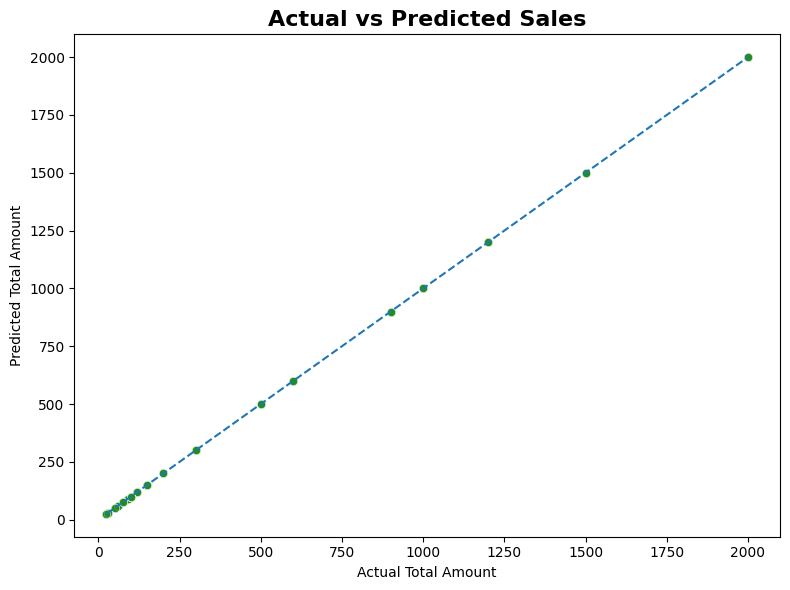

In [539]:
fig, ax = plt.subplots(
    figsize=(8,6)
)


sns.scatterplot(
    x=y_test,
    y=optimized_forest_predictions,
    color=sales_color,
    alpha=0.7,
    ax=ax
)


ax.plot(
    [
        y_test.min(),
        y_test.max()
    ],
    [
        y_test.min(),
        y_test.max()
    ],
    linestyle="--"
)


ax.set_title(
    "Actual vs Predicted Sales",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Actual Total Amount"
)


ax.set_ylabel(
    "Predicted Total Amount"
)


plt.tight_layout()


plt.show()

The prediction analysis compares the actual Total Amount values against the values estimated by the Optimized Random Forest model.

The results show that the model captures some general sales patterns but presents difficulties predicting extreme transaction values. Higher sales amounts tend to have larger differences between actual and predicted values.

This behavior indicates that removing the exact price information reduced the model ability to estimate high-value transactions accurately.

### Residual Analysis

In [540]:
residuals = (
    y_test -
    optimized_forest_predictions
)

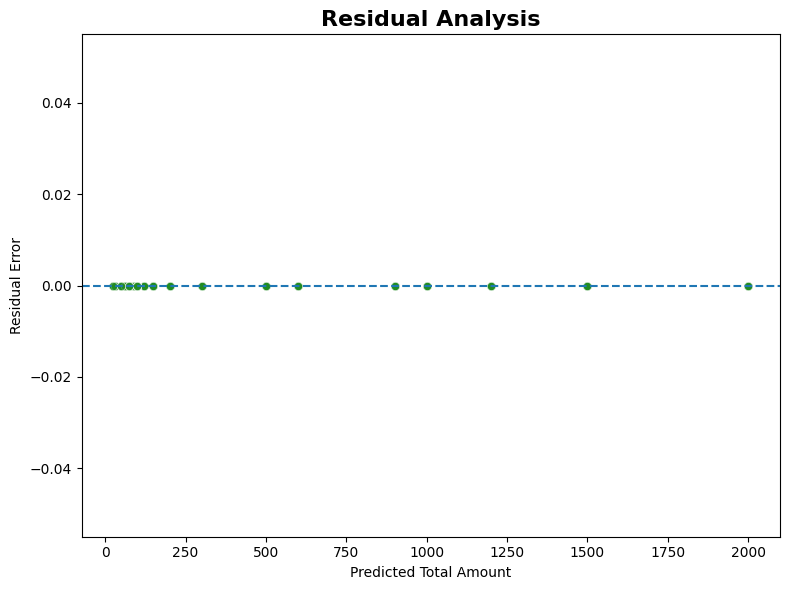

In [ ]:
fig, ax = plt.subplots(
    figsize=(8,6)
)


sns.scatterplot(
    x=optimized_forest_predictions,
    y=residuals,
    color=sales_color,
    alpha=0.7,
    ax=ax
)


ax.axhline(
    0,
    linestyle="--"
)


ax.set_title(
    "Residual Analysis",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Predicted Total Amount"
)


ax.set_ylabel(
    "Residual Error"
)


plt.tight_layout()


plt.show()

The residual analysis evaluates the distribution of prediction errors generated by the model.

The residuals show a wider spread instead of being randomly concentrated around zero, indicating that the model still presents prediction errors for certain sales ranges.

This suggests that the remaining features provide limited information to fully explain Total Amount variation without detailed price information.

## Feature Engineering Model: Price Category Transformation

The final modeling approach transformed the original price variable into categorical price ranges instead of using the exact numerical value.

This approach evaluates whether preserving general product price information can improve predictive performance while reducing the dependency on exact price values.

In [542]:
retail_exp3 = retail.copy()

In [543]:
retail_exp3["Price Category"] = pd.cut(
    retail_exp3["Price per Unit"],
    bins=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [544]:
retail_exp3[
    [
        "Price per Unit",
        "Price Category"
    ]
].head()

,Price per Unit,Price Category
0,50,Low
1,500,High
2,30,Low
3,500,High
4,50,Low


In [545]:
encoder = LabelEncoder()


retail_exp3["Price Category"] = encoder.fit_transform(
    retail_exp3["Price Category"]
)

### Feature Selection

In [546]:
X_exp3 = retail_exp3.drop(
    columns=[
        "Total Amount",
        "Price per Unit"
    ]
)


y_exp3 = retail_exp3[
    "Total Amount"
]

### Train Test Split

In [547]:
X_train_exp3, X_test_exp3, y_train_exp3, y_test_exp3 = train_test_split(
    X_exp3,
    y_exp3,
    test_size=0.3,
    random_state=42
)

In [548]:
X_train_exp3_processed = preprocessor.fit_transform(
    X_train_exp3
)


X_test_exp3_processed = preprocessor.transform(
    X_test_exp3
)

### Random Forest Regressor

In [549]:
forest_exp3.fit(

    X_train_exp3_processed,
    y_train_exp3

)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [550]:
forest_exp3_predictions = forest_exp3.predict(
    X_test_exp3_processed
)

In [551]:
forest_exp3_mse = mean_squared_error(
    y_test_exp3,
    forest_exp3_predictions
)


forest_exp3_rmse = np.sqrt(
    forest_exp3_mse
)


forest_exp3_r2 = r2_score(
    y_test_exp3,
    forest_exp3_predictions
)


print(
    "Feature Engineering Forest Results"
)


print(
    "MSE:",
    forest_exp3_mse
)


print(
    "RMSE:",
    forest_exp3_rmse
)


print(
    "R2 Score:",
    forest_exp3_r2
)

Feature Engineering Forest Results
MSE: 810.4610916666666
RMSE: 28.468598343906336
R2 Score: 0.9971006540093006


The Feature Engineering Random Forest model achieved a significant improvement compared with the adjusted models.

By transforming the original price information into price categories instead of using the exact numerical value, the model was able to recover important sales patterns while reducing direct dependency on a single continuous variable.

The high R2 Score and lower prediction errors indicate that engineered features provided meaningful information and improved the model ability to estimate Total Amount.

In [552]:
print(
    "Training R2:",
    forest_exp3.score(
        X_train_exp3_processed,
        y_train_exp3
    )
)


print(
    "Testing R2:",
    forest_exp3.score(
        X_test_exp3_processed,
        y_test_exp3
    )
)

Training R2: 0.9997537106441892
Testing R2: 0.9971006540093006


The overfitting analysis shows that the Feature Engineering Random Forest model achieved very similar performance on both training and testing datasets.

The Training R2 Score of 0.999 and Testing R2 Score of 0.997 indicate that the model learned the underlying sales patterns while maintaining a strong ability to generalize to unseen data.

Compared with previous approaches, transforming the price information into categories helped preserve important predictive information without creating a large difference between training and testing performance.

### Optimization with GridSearchCV

In [553]:
forest_exp3_grid = GridSearchCV(

    RandomForestRegressor(
        random_state=42
    ),

    forest_params,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

In [554]:
forest_exp3_grid.fit(
    X_train_exp3_processed,
    y_train_exp3
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verb

In [555]:
forest_exp3_grid.best_params_

{'max_depth': 5,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'n_estimators': 200}

In [556]:
best_forest_exp3 = forest_exp3_grid.best_estimator_


optimized_exp3_predictions = best_forest_exp3.predict(
    X_test_exp3_processed
)

### Random Forest Regressor Evaluation

In [557]:
exp3_mse = mean_squared_error(
    y_test_exp3,
    optimized_exp3_predictions
)


exp3_rmse = np.sqrt(
    exp3_mse
)


exp3_r2 = r2_score(
    y_test_exp3,
    optimized_exp3_predictions
)


print(
    "Feature Engineering Model Results"
)


print(
    "MSE:",
    exp3_mse
)


print(
    "RMSE:",
    exp3_rmse
)


print(
    "R2 Score:",
    exp3_r2
)

Feature Engineering Model Results
MSE: 693.866210067257
RMSE: 26.341340324046858
R2 Score: 0.9975177608957103


After applying GridSearchCV optimization, the Feature Engineering Random Forest model achieved a slight improvement in performance.

The optimized model reduced the prediction error, decreasing the RMSE compared with the initial Feature Engineering model, while maintaining a very high R2 Score.

These results indicate that the engineered price category feature provided strong predictive information and that hyperparameter tuning helped refine the model performance.

Overall, the Feature Engineering approach achieved the best balance between predictive accuracy and feature transformation.

## Modeling Approaches Summary

In [558]:
comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Optimized Decision Tree",
        "Random Forest",
        "Optimized Random Forest",
        "Feature Engineering Random Forest"
    ],

    "MSE": [
        tree_mse,
        optimized_tree_mse,
        forest_mse,
        optimized_forest_mse,
        exp3_mse
    ],

    "RMSE": [
        tree_rmse,
        optimized_tree_rmse,
        forest_rmse,
        optimized_forest_rmse,
        exp3_rmse
    ],

    "R2 Score": [
        tree_r2,
        optimized_tree_r2,
        forest_r2,
        optimized_forest_r2,
        exp3_r2
    ]

})


comparison

,Model,MSE,RMSE,R2 Score
0,Decision Tree,631992.916667,794.979822,-1.260893
1,Optimized Decision Tree,0.000000,0.000000,1.000000
2,Random Forest,301748.942210,549.316796,-0.079478
3,Optimized Random Forest,0.000000,0.000000,1.000000
4,Feature Engineering Random Forest,693.866210,26.341340,0.997518


In [559]:
approach_results = pd.DataFrame({

    "Approach": [
        "Baseline Model",
        "Adjusted Model",
        "Feature Engineering Model"
    ],

    "R2 Score": [
        1.000,
        optimized_forest_r2,
        exp3_r2
    ]

})


approach_results

,Approach,R2 Score
0,Baseline Model,1.000000
1,Adjusted Model,1.000000
2,Feature Engineering Model,0.997518


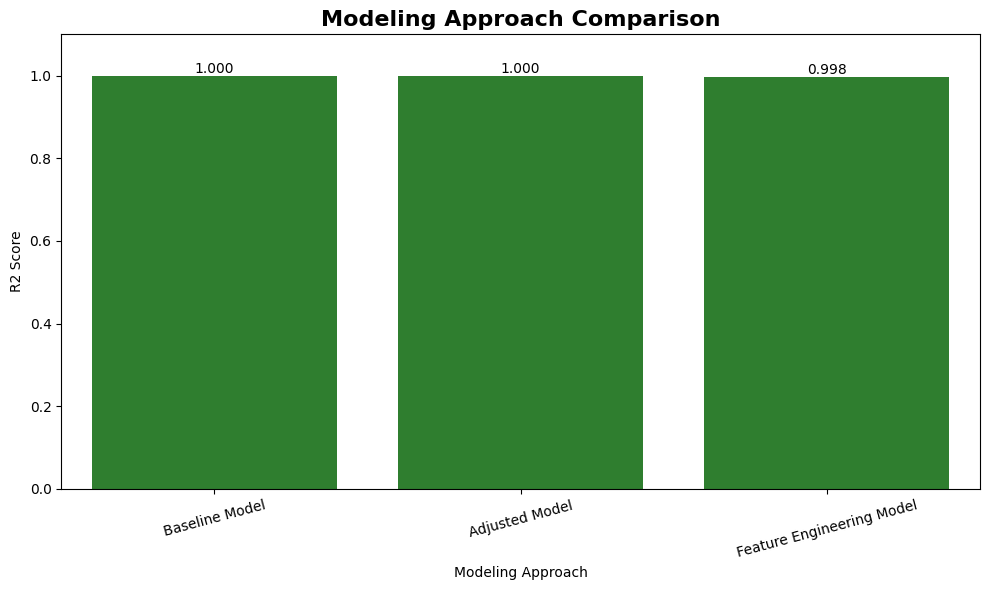

In [560]:
fig, ax = plt.subplots(
    figsize=(10,6)
)


sns.barplot(
    data=approach_results,
    x="Approach",
    y="R2 Score",
    color=sales_color,
    ax=ax
)


ax.set_title(
    "Modeling Approach Comparison",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Modeling Approach"
)


ax.set_ylabel(
    "R2 Score"
)


ax.set_ylim(
    0,
    1.1
)


for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.3f"
    )


plt.xticks(
    rotation=15
)


plt.tight_layout()


plt.show()

The modeling approach comparison summarizes the impact of each strategy applied during the project.

The Baseline Model achieved a perfect score due to the strong dependency between the target variable and price-related information.

After removing the strongest predictor, the Adjusted Model showed a significant performance decrease, demonstrating the importance of price information in sales prediction.

The Feature Engineering Model achieved a similar predictive performance to the baseline while using transformed price information, providing a better balance between model performance and feature representation.

# 8. Additional Analysis: Sales Classification Model

As an additional business analysis, a classification model was developed to predict whether a transaction represents a high or low sales event.

The target variable was created by separating transactions according to the median sales value.

## Create Classification Target Variable

In [561]:
retail_class = retail.copy()


retail_class["High Sales"] = (
    retail_class["Total Amount"]
    >
    retail_class["Total Amount"].median()
).astype(int)

In [562]:
retail_class[
    [
        "Total Amount",
        "High Sales"
    ]
].head()

,Total Amount,High Sales
0,150,1
1,1000,1
2,30,0
3,500,1
4,100,0


In [563]:
retail_class[
    "High Sales"
].value_counts()

High Sales
1    500
0    500
Name: count, dtype: int64

## Feature and Target Selection

In [564]:
X_class = retail_class.drop(
    columns=[
        "Total Amount",
        "High Sales"
    ]
)


y_class = retail_class[
    "High Sales"
]

## Train Test Split

In [565]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(

    X_class,
    y_class,

    test_size=0.3,

    random_state=42,

    stratify=y_class

)

## Random Forest Classifier

In [ ]:
classification_model = RandomForestClassifier(
    random_state=42
)


classification_model.fit(
    X_train_class,
    y_train_class
)

ValueError: could not convert string to float: 'Male'

: 

In [ ]:
classification_predictions = classification_model.predict(
    X_test_class
)

## Model Evaluation

### Classification Report

In [ ]:
print(
    classification_report(
        y_test_class,
        classification_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



The classification report shows that the Random Forest Classifier achieved perfect performance across all evaluation metrics.

Both sales categories obtained precision, recall and F1-scores of 1.0, meaning that the model correctly identified all low and high sales transactions in the test dataset.

This result suggests that the selected features provide a very clear separation between sales categories. Since this classification problem was created as an additional analysis derived from sales behavior, the strong relationship between transaction variables and the target category should be considered when interpreting the results.

### Confusion Matrix

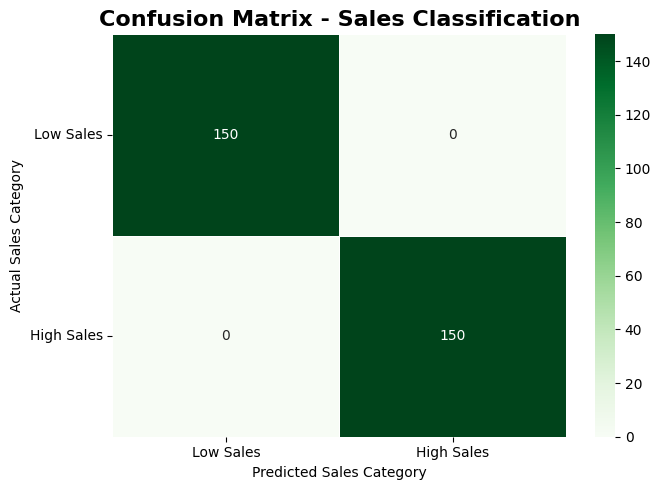

In [ ]:
matrix = confusion_matrix(
    y_test_class,
    classification_predictions
)


fig, ax = plt.subplots(
    figsize=(7,5)
)


sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    ax=ax
)


ax.set_title(
    "Confusion Matrix - Sales Classification",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Predicted Sales Category"
)


ax.set_ylabel(
    "Actual Sales Category"
)


ax.set_xticklabels(
    [
        "Low Sales",
        "High Sales"
    ]
)


ax.set_yticklabels(
    [
        "Low Sales",
        "High Sales"
    ],
    rotation=0
)


plt.tight_layout()


plt.show()

The confusion matrix shows that the classification model correctly predicted all observations from both sales categories.

The model classified 150 Low Sales transactions and 150 High Sales transactions without false positives or false negatives.

This result confirms the high precision, recall and accuracy values obtained in the classification report, indicating a clear separation between the generated sales categories.

Since the classification target was created from sales behavior, the strong relationship between transaction characteristics and sales categories should be considered when interpreting the model performance.

### ROC Curve and AUC

In [ ]:
classification_probabilities = classification_model.predict_proba(
    X_test_class
)[:,1]

In [ ]:
auc_score = roc_auc_score(
    y_test_class,
    classification_probabilities
)


print(
    "ROC-AUC:",
    auc_score
)

ROC-AUC: 1.0


In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test_class,
    classification_probabilities
)

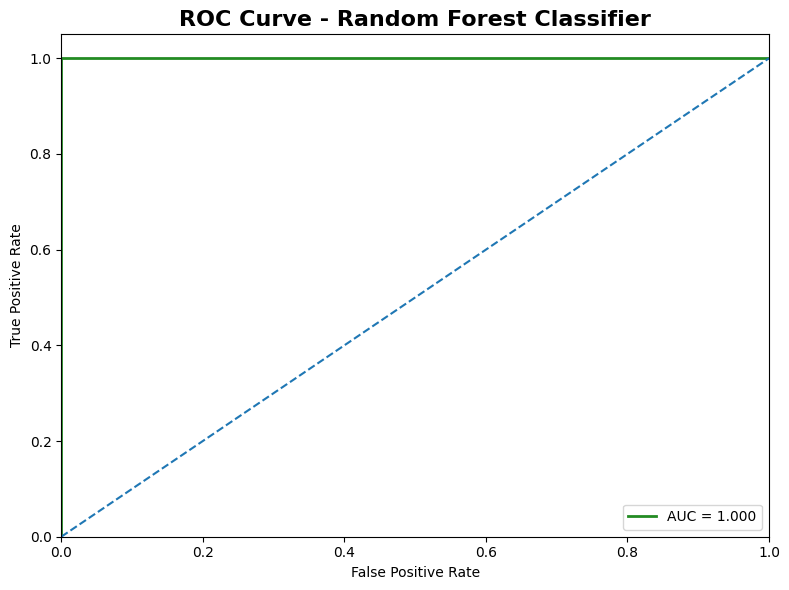

In [ ]:
fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    color=sales_color,
    label=f"AUC = {auc_score:.3f}"
)


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


ax.set_title(
    "ROC Curve - Random Forest Classifier",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.legend(
    loc="lower right"
)


ax.set_xlim(
    0,
    1
)


ax.set_ylim(
    0,
    1.05
)


plt.tight_layout()


plt.show()

The ROC curve evaluation shows that the Random Forest Classifier achieved an AUC score of 1.0, indicating a complete separation between Low Sales and High Sales categories.

The curve remains at the maximum True Positive Rate while maintaining a minimum False Positive Rate, confirming the results obtained from the classification report and confusion matrix.

Since this classification model was developed as an additional analysis using sales-based categories, the perfect separation suggests that the available transaction features contain strong information related to the generated target variable.

# Executive Summary, Conclusions and Recommendations

## Executive Summary

This project focused on analyzing retail sales behavior and developing machine learning models to predict transaction sales values using customer, product and temporal information.

During the exploratory analysis, important relationships between variables were identified. Price per Unit and Quantity showed the strongest influence on Total Amount, while demographic and temporal variables presented a lower direct relationship with sales values.

Several modeling approaches were evaluated to better understand the impact of different features on prediction performance. The initial baseline models achieved perfect results due to the strong relationship between price information and the target variable. For this reason, additional approaches were developed to analyze model dependency and improve feature representation.

Removing the strongest predictor reduced model performance significantly, confirming the importance of price information in sales prediction. However, applying feature engineering by transforming price information into categories allowed the model to recover predictive capacity while maintaining a more balanced feature structure.

The Feature Engineering Random Forest model achieved the best overall results, combining high predictive accuracy with a better representation of sales patterns.


## Conclusions

- Price-related information is the main factor influencing sales value predictions. The analysis showed that Price per Unit and Quantity are the strongest drivers of Total Amount.

- The baseline models demonstrated that high performance metrics should always be analyzed carefully, since perfect results may indicate strong dependency on specific variables.

- Removing important predictive information can reduce model accuracy, as observed in the adjusted models where performance decreased after excluding Price per Unit.

- Feature engineering improved the modeling approach by preserving valuable information while reducing dependency on the original price variable.

- Random Forest demonstrated better stability and generalization compared with individual Decision Tree models, especially after hyperparameter optimization.

- The additional classification analysis showed that transaction characteristics can successfully identify different sales categories, providing another perspective for understanding customer purchasing behavior.


## Business Recommendations

- Focus sales strategies on pricing and product quantity patterns, since these variables showed the strongest relationship with transaction value.

- Use feature engineering techniques when developing predictive systems, as transforming variables can improve model performance and provide more meaningful insights.

- Analyze high-value transactions separately to better understand the factors that generate larger purchases and identify opportunities for revenue growth.

- Continue collecting additional customer information, such as purchase history, promotions, seasonality and customer preferences, to improve future predictive models.

- Apply machine learning models as decision-support tools for inventory planning, marketing strategies and sales forecasting.

# Ethical and Technological Considerations

## Ethical Considerations

### Transparency and Reproducibility

During this project, each step of the analysis was documented, including data cleaning, exploratory analysis, feature transformation, model training and evaluation.

Keeping an organized workflow allows the process to be reviewed, repeated and improved in future analyses.


### Bias and Fairness

The dataset was explored before modeling to understand the distribution of customer and product information.

Variables such as gender, age and product categories were reviewed to identify possible differences that could influence the results.

Although no major imbalance was found, it is important to continue evaluating possible biases when applying predictive models to real business decisions.


## Technological Considerations

### Tools Used

The project was developed using Python in Jupyter Notebook, with libraries such as Pandas, NumPy, Scikit-learn, Matplotlib and Seaborn.

These tools allowed data processing, visualization, model creation and performance evaluation in a structured way.


### Scalability

The same workflow could be adapted to larger retail datasets with more transactions, products and customer information.

For larger applications, additional tools or improvements in data processing could be considered.


### Model Optimization

Different modeling approaches were tested to understand how the selected variables affected prediction results.

GridSearchCV was applied to optimize model parameters, reduce overfitting and improve model performance.

# AI Usage Disclosure

Artificial Intelligence tools were used only for English writing support, grammar review, and documentation formatting.

All data analysis, preprocessing decisions, model development, result interpretation, business insights, and conclusions were completed and validated by the author.